# Benchmarking Fleets compute profiles with SQD IEF-PCM

This notebook demonstrates how **larger Fleets compute profiles reduce the runtime**
of the SQD IEF-PCM function template, using the same methanol (14e, 12o) workload as
`deploy_and_run.ipynb`.

## What this demo isolates, and why

The SQD IEF-PCM workflow has two very different stages:

- **Mapping / QPU sampling** — SCF, CCSD, LUCJ circuit build, transpile, and the hardware
  sampler job. This is *serial* and *identical* regardless of compute profile.
- **SQD post-processing** — for each S-CORE iteration, `number_of_batches` independent
  eigenstate solves (the PySCF selected-CI Davidson diagonalization). This is the part
  that *parallelizes* across CPU cores, one batch per worker process.

A prior run of `deploy_and_run.ipynb` measured (see its `metadata.resources_usage`):

| Stage | Time |
|---|---|
| MAPPING | ~6 s |
| EXECUTING_QPU | ~90 s |
| **POST_PROCESSING** | **~282 s** |

Post-processing dominates — that is the stage a bigger profile speeds up. So this demo:

1. **Bypasses the QPU.** We generate the LUCJ counts **once**, save them to a file that
   is uploaded with the function, and every run reads that same file
   (`count_dict_file_name`). Every profile therefore diagonalizes *identical* input and
   the only variable is the compute profile — no QPU queue noise, no run-to-run count
   variation, no repeated QPU cost.
2. **Fixes `number_of_batches = 48`.** The entrypoint parallelizes at
   `min(number_of_batches, os.cpu_count())`, so the batch count must be large enough to
   keep the big profiles busy. With 48 batches:

   | Profile | CPU | Waves = ceil(48 / cpu) | Expected post-processing time |
   |---|---|---|---|
   | `8x32` | 8 | 6 | baseline |
   | `16x128` | 16 | 3 | ~2× faster |
   | `48x768` | 48 | 1 | ~6× faster |

   (We stop at 48 cores: with only 48 batches, a 128-core profile would tie `48x768`
   because 80 of its cores would sit idle — a useful point about not over-provisioning
   past your batch count, but it makes for a flat last data point in a speedup chart.)

> **Note on totals vs. stages.** Because MAPPING is skipped and the QPU is bypassed, the
> job's total wall-clock here is essentially the post-processing stage plus fixed
> container startup. We report the `POST_PROCESSING` CPU_TIME from the result metadata as
> the headline number, since that is the quantity the profile actually changes.


## Requirements

Same client versions as `deploy_and_run.ipynb`, plus `matplotlib` for the chart and
`qiskit-aer` to generate the counts file locally.

In [5]:
from qiskit_ibm_catalog import __version__ as catalog_version
from qiskit_ibm_runtime import __version__ as runtime_version

print("qiskit-ibm-catalog: ", catalog_version)
print("qiskit-ibm-runtime: ", runtime_version)

qiskit-ibm-catalog:  0.20.0
qiskit-ibm-runtime:  0.49.0


## 1. Authentication

As in the main notebook, authenticate to Qiskit Serverless. Replace the token/instance
with your own saved account.

In [ ]:
from qiskit_ibm_catalog import QiskitServerless

# Authenticate to the remote cluster
token = "MY_TOKEN"
instance = "MY_INSTANCE"

serverless = QiskitServerless(token=token, instance=instance)

qiskit_runtime_service._discover_account:WARNING:2026-09-29 13:28:21,058: Loading account with the given token. A saved account will not be used.


## 2. Define the methanol workload

Identical molecule / solvent / LUCJ inputs to `deploy_and_run.ipynb`. The **only** change
is in `sqd_options`: `number_of_batches` is raised to **48** so the larger profiles have
enough independent work to parallelize. `sqd_iterations` and `samples_per_batch` are held
fixed across every run so the compute profile is the sole variable (and
`samples_per_batch` is kept small so each batch is a fast, sparse diagonalization
rather than a near-full-CI solve -- see the code cell below).

In [7]:
NUMBER_OF_BATCHES = 48  # the parallel width of the demo; see the table above

molecule = {
    "atom": """
    O -0.04559 -0.75076 -0.00000;
    C -0.04844 0.65398 -0.00000;
    H 0.85330 -1.05128 -0.00000;
    H -1.08779 0.98076 -0.00000;
    H 0.44171 1.06337 0.88811;
    H 0.44171 1.06337 -0.88811
    """,
    "basis": "cc-pvdz",
    "spin": 0,
    "charge": 0,
    "verbosity": 0,
    "number_of_active_orb": 12,
    "number_of_active_alpha_elec": 7,
    "number_of_active_beta_elec": 7,
    "avas_selection": ["%d O %s" % (k, x) for k in [0] for x in ["2s", "2px", "2py", "2pz"]]
    + ["%d C %s" % (k, x) for k in [1] for x in ["2s", "2px", "2py", "2pz"]]
    + ["%d H 1s" % k for k in [2, 3, 4, 5]],
}

solvent_options = {
    "method": "IEF-PCM",
    "eps": 78.3553,
}

lucj_options = {
    "initial_layout": [
        0,
        14,
        18,
        19,
        20,
        33,
        39,
        40,
        41,
        53,
        60,
        61,
        2,
        3,
        4,
        15,
        22,
        23,
        24,
        34,
        43,
        44,
        45,
        54,
    ],
    "dynamical_decoupling_choice": True,
    "twirling_choice": True,
    "number_of_shots": 200000,
    "optimization_level": 2,
}

# samples_per_batch is deliberately small: for (14e, 12o) the full CI space is
# only 792 x 792 = 627,264 determinants, so a large samples_per_batch makes each
# batch a near-full-CI solve (hundreds of thousands of dimensions) that takes
# many minutes each -- which would dominate the wall clock and swamp the
# core-scaling signal this demo is trying to show. A small value keeps each batch
# a fast, genuinely sparse diagonalization so the runtime is dominated by *how
# many batches run in parallel*, which is exactly what the compute profile
# controls.
# blas_threads_per_worker controls how many BLAS/OpenMP threads each worker
# process may use inside its selected-CI Davidson solve. Leaving it None lets the
# entrypoint choose automatically: it gives each worker roughly (2 * cores /
# n_workers) threads, so on a profile with more cores than batches the workers
# ALSO get more threads each -- a bigger profile then wins on two axes at once
# (more concurrent batches AND faster per-batch solves), not just concurrency.
# Setting it to 1 reproduces the earlier one-thread-per-worker behavior; sweep
# 1 / 2 / 3 / 5 and compare parallel_solve_time (surfaced in the results below)
# to find the optimum for a given profile.
BLAS_THREADS_PER_WORKER = None  # None = auto; or an int to pin/sweep

sqd_options = {
    "sqd_iterations": 3,
    "number_of_batches": NUMBER_OF_BATCHES,
    "samples_per_batch": 200,
    "max_davidson_cycles": 200,
    "blas_threads_per_worker": BLAS_THREADS_PER_WORKER,
}

## 3. How the fixed LUCJ counts are produced (once, on the QPU)

To make every compute profile diagonalize *identical* input, all runs share one set of
LUCJ measurement counts. Rather than generating them locally (which would need `ffsim` /
`pyscf` / `qiskit-aer` installed on your machine), we let the **function itself** produce
them on the first run and cache them for the rest:

- The entrypoint takes a `count_dict_file_name`. On the **first** run the file does not
  exist yet, so the function samples the LUCJ circuit on the QPU and **writes** the counts
  to that file.
- The file lives under `/function_user_data/` inside the container, a mount that is
  **function-scoped** (shared across every job of this function) and writable. So **every
  subsequent** run of the same function finds the file, reads it, and **skips the QPU** —
  diagonalizing exactly the same counts.

The result: the QPU is sampled once; the compute-profile sweep that follows reuses those
counts, so the only thing varying across the sweep is the compute profile. Nothing is
generated on your laptop.

> The counts cache key is the filename below. To force a fresh QPU sample (new counts),
> change the filename or delete the cached file.

In [8]:
# Name of the shared LUCJ counts cache. The first run creates it on the QPU; later
# runs reuse it. It is resolved inside the container against /function_user_data/
# (function-scoped + writable), so it persists across every run of this function.
COUNTS_CACHE = "methanol_lucj_counts.txt"

## 4. Upload the function with a sizes catalog

We upload a dedicated benchmark function (`sqd_pcm_benchmark_fleets`) whose `sizes_map`
declares the three profiles we sweep. Because `source_files/methanol_counts.txt` now
exists, it is uploaded alongside the entrypoint.

In [9]:
from qiskit_ibm_catalog import QiskitFunction

# Label -> compute profile. Labels are your choice; these map onto the CPU-only
# Fleets profiles (cpu x memory GB). We skip 128x1500 for this 48-batch sweep.
SIZES_MAP = {
    "s": "8x32",  # 8 CPU,  32 GB
    "m": "16x128",  # 16 CPU, 128 GB
    "l": "48x768",  # 48 CPU, 768 GB
}

benchmark = QiskitFunction(
    title="sqd_pcm_benchmark_fleets",
    entrypoint="sqd_pcm_entrypoint.py",
    working_dir="./source_files/",  # uploads the entrypoint + methanol_counts.txt
    runner="fleets",
    sizes_map=SIZES_MAP,
    default_size="s",
)
serverless.upload(benchmark)
print(benchmark)

QiskitFunction(sqd_pcm_benchmark_fleets)


In [10]:
benchmark = serverless.load("sqd_pcm_benchmark_fleets")
print("sizes:", benchmark.sizes())
print("default size:", benchmark.get_default_size())

sizes: {'s': '8x32', 'm': '16x128', 'l': '48x768'}
default size: s


## 5. Run the sweep

For each profile label we submit one job, passing `count_dict_file_name` so the run
bypasses the QPU and diagonalizes the fixed counts file. The jobs are submitted, then
polled to completion. `backend_name` is still required by the entrypoint signature but is
unused on the counts-file path.

> These jobs are independent, so you can let them queue concurrently on Fleets. If you'd
> rather run strictly one at a time (e.g. to avoid contention on a shared demo account),
> set `WAIT_SEQUENTIALLY = True`.

In [11]:
import time

WAIT_SEQUENTIALLY = False
SWEEP = ["s", "m", "l"]  # -> 8x32, 16x128, 48x768


def submit(size_label):
    return benchmark.run(
        function_size=size_label,
        backend_name="ibm_kingston",  # unused on the counts-file path
        molecule=molecule,
        solvent_options=solvent_options,
        lucj_options=lucj_options,
        sqd_options=sqd_options,
        count_dict_file_name="methanol_counts.txt",  # resolved next to the entrypoint
    )


def wait(job):
    while True:
        s = job.status()
        if s in ("DONE", "ERROR"):
            return s
        time.sleep(5)


jobs = {}
for label in SWEEP:
    jobs[label] = submit(label)
    print(f"submitted {label} ({SIZES_MAP[label]}): {jobs[label].job_id}")
    if WAIT_SEQUENTIALLY:
        print(f"  -> {wait(jobs[label])}")

submitted s (8x32): e524ec58-b543-4012-a350-4b6b894c21f2
submitted m (16x128): f9f4db24-d8ff-454d-809e-b0d489f4acd4
submitted l (48x768): 9f93a8f8-7471-4d79-8190-02ea6c085f42


Wait for all jobs to finish and pull the post-processing time from each result's
metadata.

In [12]:
records = []
for label in SWEEP:
    job = jobs[label]
    status = wait(job)
    profile = SIZES_MAP[label]
    cpu = int(profile.split("x")[0])
    if status != "DONE":
        print(f"{label} ({profile}) ended in {status}; logs:\n{job.logs()}")
        records.append(
            {
                "label": label,
                "profile": profile,
                "cpu": cpu,
                "post_processing_s": float("nan"),
                "parallel_solve_s": float("nan"),
                "serial_prep_s": float("nan"),
                "warmup_s": float("nan"),
                "workers": None,
                "threads_per_worker": None,
                "status": status,
            }
        )
        continue
    meta = job.result()["metadata"]
    pp = meta["resources_usage"]["RUNNING: POST_PROCESSING"]["CPU_TIME"]
    # The breakdown (added to the entrypoint) splits post-processing into the
    # parallel solve vs. the serial prep and worker startup. parallel_solve_time
    # is the part a bigger profile / more threads actually reduces, so it is the
    # right quantity to compare across profiles and thread settings; serial_prep
    # is the Amdahl floor that no profile touches.
    bd = meta.get("post_processing_breakdown", {})
    rec = {
        "label": label,
        "profile": profile,
        "cpu": cpu,
        "post_processing_s": pp,
        "parallel_solve_s": bd.get("parallel_solve_time", float("nan")),
        "serial_prep_s": bd.get("serial_prep_time", float("nan")),
        "warmup_s": bd.get("worker_warmup_time", float("nan")),
        "workers": bd.get("max_workers"),
        "threads_per_worker": bd.get("blas_threads_per_worker"),
        "status": status,
    }
    records.append(rec)
    print(
        f"{label} ({profile}, {cpu} CPU): post-proc {pp:.1f} s "
        f"[solve {rec['parallel_solve_s']:.1f} s, prep {rec['serial_prep_s']:.1f} s, "
        f"{rec['workers']}w x {rec['threads_per_worker']}t]"
    )

s (8x32, 8 CPU): post-proc 2623.9 s [solve 2542.0 s, prep 74.0 s, 8w x 2t]
m (16x128, 16 CPU): post-proc 1109.6 s [solve 1030.6 s, prep 71.9 s, 16w x 2t]
l (48x768, 48 CPU): post-proc 776.8 s [solve 703.8 s, prep 64.3 s, 48w x 4t]


## 6. Results

Tabulate the post-processing time per profile and compute the speedup relative to the
smallest profile (`8x32`).

In [13]:
import math

baseline = next((r["post_processing_s"] for r in records if r["profile"] == "8x32"), None)

# Two columns matter: total post-processing (what the user waits for) and
# parallel_solve_s (the part a profile/threads actually speed up). The gap
# between them is the serial prep floor (Amdahl), which no profile reduces.
hdr = (
    f"{'profile':<12}{'CPU':>5}{'w x t':>8}{'post-proc':>12}{'solve':>10}{'prep':>9}{'speedup':>10}"
)
print(hdr)
print("-" * len(hdr))
for r in sorted(records, key=lambda x: x["cpu"]):
    pp = r["post_processing_s"]
    speedup = f"{baseline / pp:.2f}x" if (baseline and not math.isnan(pp)) else "-"
    wt = f"{r['workers']}x{r['threads_per_worker']}" if r.get("workers") else "-"
    print(
        f"{r['profile']:<12}{r['cpu']:>5}{wt:>8}{pp:>12.1f}"
        f"{r['parallel_solve_s']:>10.1f}{r['serial_prep_s']:>9.1f}{speedup:>10}"
    )

profile       CPU   w x t   post-proc     solve     prep   speedup
------------------------------------------------------------------
8x32            8     8x2      2623.9    2542.0     74.0     1.00x
16x128         16    16x2      1109.6    1030.6     71.9     2.36x
48x768         48    48x4       776.8     703.8     64.3     3.38x


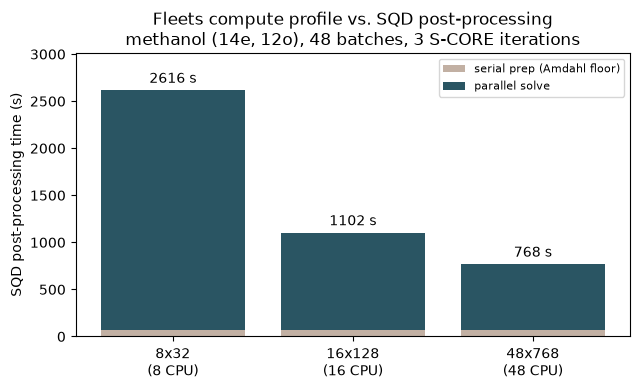

In [16]:
import matplotlib.pyplot as plt

valid = [
    r for r in sorted(records, key=lambda x: x["cpu"]) if not math.isnan(r["post_processing_s"])
]
labels = [f"{r['profile']}\n({r['cpu']} CPU)" for r in valid]
solve = [r["parallel_solve_s"] for r in valid]
prep = [r["serial_prep_s"] for r in valid]

# Stacked bars: the parallel solve (shrinks with the profile) on top of the
# serial prep floor (flat across profiles). This shows both the win and its
# limit in one picture.
import numpy as np

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(6.5, 4))
b1 = ax.bar(x, prep, color="#c2b0a3", label="serial prep (Amdahl floor)")
b2 = ax.bar(x, solve, bottom=prep, color="#2a5563", label="parallel solve")
ax.set_xticks(x, labels)
ax.set_ylabel("SQD post-processing time (s)")
ax.set_title(
    f"Fleets compute profile vs. SQD post-processing\n"
    f"methanol (14e, 12o), {NUMBER_OF_BATCHES} batches, "
    f"{sqd_options['sqd_iterations']} S-CORE iterations"
)
totals = [p + s for p, s in zip(prep, solve)]
ax.bar_label(b2, labels=[f"{t:.0f} s" for t in totals], padding=3)
ax.legend(loc="upper right", fontsize=8)
ax.margins(y=0.15)
fig.tight_layout()
plt.show()

### Reading the result

The stacked bars separate the two parts of post-processing:

- **parallel solve** (top) — the per-batch diagonalizations. This is what more cores
  and more BLAS threads per worker reduce, so it should fall as the profile grows.
- **serial prep** (bottom) — config recovery + subsampling between S-CORE iterations.
  It is single-threaded and roughly constant across profiles: the **Amdahl floor** that
  no profile removes.

**Caveats worth stating in the demo:**

- **Bigger profiles win on two axes.** With `number_of_batches` fixed, a larger profile
  runs more batches concurrently *and* (via the auto `blas_threads_per_worker`) gives each
  worker more BLAS threads, so each solve is also faster. Worker startup was measured at
  ~3 s (`worker_warmup_time`) — negligible, not a real cost.
- **The speedup is sub-linear** and floored by `serial_prep`. Once the parallel solve is
  small relative to prep, adding cores stops helping.
- **More cores than batches buys nothing on the concurrency axis.** With `number_of_batches`
  batches, only that many workers run; extra cores instead go to more threads per worker
  (helpful up to a point). Raise `number_of_batches` to use a very large profile fully.
- **Memory scales with concurrency, not speed.** Each worker holds its own active-space
  integrals and Davidson vectors, so RAM must cover `n_workers x per-batch footprint`.
  More RAM prevents OOM; it does not by itself make the job faster.
- **Thread count has an optimum — sweep it.** `blas_threads_per_worker` trades per-solve
  speed against how many batches run at once. Re-run with a few values (1 / 2 / 3 / 5) and
  compare `parallel_solve_s` in the table; the auto default is a reasonable start, not
  guaranteed optimal for every profile.

**Note on comparing to the older Ray runtime.** Earlier Ray-based numbers for this
template were produced on an older dependency stack (qiskit-addon-sqd ~0.11, pyscf ~2.9);
the Fleets image pins newer versions (sqd 0.13.1, pyscf 2.13.1). Part of any residual
runtime difference between Ray and Fleets can therefore be the selected-CI solver version,
not the execution runtime — so treat cross-runtime comparisons as approximate unless both
run the same library versions.